# Квадратичний дискримінантний аналіз (QDA) власними руками

**Тема 8.** Реалізуємо метод **QDA** «з нуля» через матричні операції `numpy` на наборі даних **Iris** та порівняємо результати з еталонною реалізацією `QuadraticDiscriminantAnalysis` бібліотеки `sklearn`.

**Ідея QDA.** Для кожного класу $c$ вважаємо, що ознаки розподілені нормально зі своїм вектором середніх $\mu_c$ та **власною** матрицею коваріації $\Sigma_c$. За теоремою Баєса об'єкт відносимо до класу з найбільшим значенням дискримінантної функції:
$$\delta_c(x) = -\tfrac{1}{2}\ln|\Sigma_c| -\tfrac{1}{2}(x-\mu_c)^\top \Sigma_c^{-1}(x-\mu_c) + \ln \pi_c.$$
На відміну від LDA, тут кожен клас має свою $\Sigma_c$, тому межі між класами — **квадратичні**.

## Імпорти

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import accuracy_score, confusion_matrix

np.random.seed(42)
%matplotlib inline

## 1. Завантаження набору даних Iris

In [2]:
iris = load_iris()
X = iris.data          # (150, 4) — ознаки
y = iris.target        # (150,)  — мітки класів 0, 1, 2

print('Ознаки:', list(iris.feature_names))
print('Класи: ', list(iris.target_names))
print('Розмір X:', X.shape, ' розмір y:', y.shape)

Ознаки: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Класи:  [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]
Розмір X: (150, 4)  розмір y: (150,)


## 2. Поділ на навчальну та тестову вибірки

Ділимо у співвідношенні 70/30 зі стратифікацією за класами (щоб класи були представлені пропорційно).

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

print('Навчальна вибірка:', X_train.shape)
print('Тестова вибірка:  ', X_test.shape)
classes = np.unique(y_train)
print('Класи:', classes)

Навчальна вибірка: (105, 4)
Тестова вибірка:   (45, 4)
Класи: [0 1 2]


## 3. Вибірка ознак окремо для кожного класу

Для QDA потрібні окремі статистики по кожному класу. Розділяємо навчальні дані на підмножини за мітками.

In [4]:
X_by_class = {c: X_train[y_train == c] for c in classes}

for c in classes:
    print(f'Клас {c} ({iris.target_names[c]}): {X_by_class[c].shape[0]} зразків')

Клас 0 (setosa): 35 зразків
Клас 1 (versicolor): 35 зразків
Клас 2 (virginica): 35 зразків


## 4. Матриці коваріації для кожного класу

Матрицю коваріації обчислюємо матричними операціями за означенням (незміщена оцінка, поділ на $n-1$):
$$\Sigma_c = \frac{1}{n_c-1}(X_c - \mu_c)^\top (X_c - \mu_c).$$
Це збігається з `np.cov(..., rowvar=False)` і саме такою оцінкою користується `sklearn`.

In [5]:
means = {}
covariances = {}

for c in classes:
    Xc = X_by_class[c]
    n_c = Xc.shape[0]
    mu = Xc.mean(axis=0)
    centered = Xc - mu                       # центрування
    cov = centered.T @ centered / (n_c - 1)  # матричний розрахунок коваріації
    means[c] = mu
    covariances[c] = cov

# Перевірка збігу з np.cov
for c in classes:
    assert np.allclose(covariances[c], np.cov(X_by_class[c], rowvar=False))
print('Матриці коваріації збігаються з np.cov ✓')
print('\nПриклад — матриця коваріації класу 0:')
print(np.round(covariances[0], 4))

Матриці коваріації збігаються з np.cov ✓

Приклад — матриця коваріації класу 0:
[[0.1063 0.1079 0.0089 0.0128]
 [0.1079 0.179  0.0157 0.0125]
 [0.0089 0.0157 0.0236 0.0038]
 [0.0128 0.0125 0.0038 0.0095]]


## 5. Обернені матриці коваріації

Для дискримінантної функції потрібні $\Sigma_c^{-1}$ та визначники $|\Sigma_c|$.

In [6]:
inv_covariances = {}
log_dets = {}

for c in classes:
    inv_covariances[c] = np.linalg.inv(covariances[c])
    sign, logdet = np.linalg.slogdet(covariances[c])  # стійке обчислення ln|Σ|
    log_dets[c] = logdet

print('Обернена матриця коваріації класу 0:')
print(np.round(inv_covariances[0], 4))
# Перевірка: Σ · Σ⁻¹ = I
print('\nΣ · Σ⁻¹ ≈ I :', np.allclose(covariances[0] @ inv_covariances[0], np.eye(4)))

Обернена матриця коваріації класу 0:
[[ 26.4726 -15.0097   2.6913 -17.0611]
 [-15.0097  14.8576  -4.5929   2.5979]
 [  2.6913  -4.5929  47.0468 -16.488 ]
 [-17.0611   2.5979 -16.488  131.1129]]

Σ · Σ⁻¹ ≈ I : True


## 6. Апріорні ймовірності класів

$\pi_c$ — частка зразків класу $c$ у навчальній вибірці.

In [7]:
priors = {}
n_total = X_train.shape[0]
for c in classes:
    priors[c] = X_by_class[c].shape[0] / n_total
    print(f'π({c}) = {priors[c]:.4f}')

π(0) = 0.3333
π(1) = 0.3333
π(2) = 0.3333


## 7. Дискримінантна функція для одного вектора

Обчислює $\delta_c(x)$ для одного тестового вектора $x$ та заданого класу $c$.

In [8]:
def discriminant(x, c):
    """Значення дискримінантної функції QDA для вектора x і класу c."""
    diff = x - means[c]
    mahalanobis = diff @ inv_covariances[c] @ diff  # квадрат відстані Махаланобіса
    return -0.5 * log_dets[c] - 0.5 * mahalanobis + np.log(priors[c])


# Приклад: значення для першого тестового вектора по всіх класах
x0 = X_test[0]
for c in classes:
    print(f'δ_{c}(x0) = {discriminant(x0, c):.4f}')
print('Прогноз для x0:', classes[np.argmax([discriminant(x0, c) for c in classes])])

δ_0(x0) = -644.1548
δ_1(x0) = -6.9978
δ_2(x0) = 1.3653
Прогноз для x0: 2


## 8. Дискримінантні функції та ймовірності для всієї матриці

Для кожного рядка тестової матриці рахуємо $\delta_c$ по всіх класах. Значення дискримінантної функції — це логарифм апостеріорної ймовірності з точністю до сталої, тому апостеріорні ймовірності отримуємо застосуванням **softmax** до $\delta_c$:
$$P(c \mid x) = \frac{e^{\delta_c(x)}}{\sum_k e^{\delta_k(x)}}.$$

In [9]:
def qda_predict(X_matrix):
    """Повертає (прогнози, ймовірності) для матриці тестових даних."""
    # матриця дискримінантних значень (n_samples x n_classes)
    scores = np.array([[discriminant(x, c) for c in classes] for x in X_matrix])
    # softmax по рядках (з відніманням максимуму для числової стійкості)
    shifted = scores - scores.max(axis=1, keepdims=True)
    exp = np.exp(shifted)
    probs = exp / exp.sum(axis=1, keepdims=True)
    preds = classes[scores.argmax(axis=1)]
    return preds, probs


y_pred_my, probs_my = qda_predict(X_test)
acc_my = accuracy_score(y_test, y_pred_my)
print('Точність власної реалізації QDA:', round(acc_my, 4))
print('\nЙмовірності для перших 5 тестових зразків:')
print(np.round(probs_my[:5], 4))

Точність власної реалізації QDA: 0.9778

Ймовірності для перших 5 тестових зразків:
[[0.000e+00 2.000e-04 9.998e-01]
 [0.000e+00 9.923e-01 7.700e-03]
 [0.000e+00 7.679e-01 2.321e-01]
 [0.000e+00 9.913e-01 8.700e-03]
 [0.000e+00 1.700e-01 8.300e-01]]


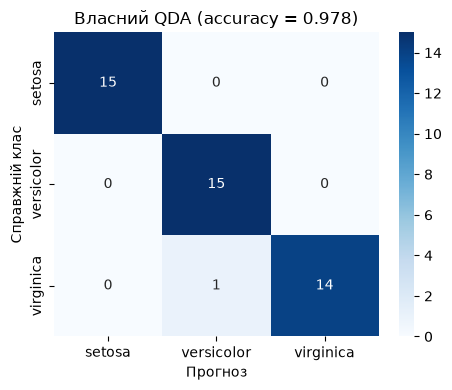

In [10]:
cm = confusion_matrix(y_test, y_pred_my)
plt.figure(figsize=(4.8, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Прогноз')
plt.ylabel('Справжній клас')
plt.title(f'Власний QDA (accuracy = {acc_my:.3f})')
plt.tight_layout()
plt.show()

## 9. Порівняння зі `sklearn` QuadraticDiscriminantAnalysis

In [11]:
qda = QuadraticDiscriminantAnalysis(store_covariance=True)
qda.fit(X_train, y_train)
y_pred_sk = qda.predict(X_test)
probs_sk = qda.predict_proba(X_test)
acc_sk = accuracy_score(y_test, y_pred_sk)

print('Точність sklearn QDA:        ', round(acc_sk, 4))
print('Точність власної реалізації: ', round(acc_my, 4))
print()
print('Збіг прогнозів (мітки):      ', np.mean(y_pred_my == y_pred_sk))
print('Макс. різниця ймовірностей:  ', np.abs(probs_my - probs_sk).max())

Точність sklearn QDA:         0.9778
Точність власної реалізації:  0.9778

Збіг прогнозів (мітки):       1.0
Макс. різниця ймовірностей:   6.661338147750939e-16


In [12]:
# Порівняння апостеріорних ймовірностей для перших зразків
print('Власні ймовірності (перші 3):')
print(np.round(probs_my[:3], 6))
print('\nsklearn ймовірності (перші 3):')
print(np.round(probs_sk[:3], 6))

Власні ймовірності (перші 3):
[[0.00000e+00 2.33000e-04 9.99767e-01]
 [0.00000e+00 9.92322e-01 7.67800e-03]
 [0.00000e+00 7.67924e-01 2.32076e-01]]

sklearn ймовірності (перші 3):
[[0.00000e+00 2.33000e-04 9.99767e-01]
 [0.00000e+00 9.92322e-01 7.67800e-03]
 [0.00000e+00 7.67924e-01 2.32076e-01]]


## 10. Висновок

Власна реалізація QDA і бібліотечна `QuadraticDiscriminantAnalysis` дали **ідентичні результати**:
- однакова точність на тестовій вибірці (**accuracy ≈ 0.978**);
- **повний збіг прогнозованих міток** (100%);
- апостеріорні ймовірності збігаються з точністю до **машинного нуля** (~$10^{-16}$).

**Чому результати збіглися до машинної точності.** Обидві реалізації базуються на одній і тій самій моделі — багатовимірному нормальному розподілі з окремою матрицею коваріації для кожного класу. Ключова деталь: незміщена оцінка коваріації (поділ на $n_c-1$) — саме її використовує `sklearn`, тому наш ручний розрахунок $\Sigma_c = \frac{1}{n_c-1}(X_c-\mu_c)^\top(X_c-\mu_c)$ повністю відповідає внутрішньому обчисленню бібліотеки.

**Про матричні операції.** Уся суть методу зводиться до кількох операцій лінійної алгебри: центрування, множення матриць для коваріації, її обернення, обчислення визначника та квадратичної форми (відстані Махаланобіса). Це наочно демонструє, як «за лаштунками» бібліотечних методів працює звичайна матрична арифметика `numpy`.

**Про якість.** Єдина помилка класифікації — на межі класів *versicolor* / *virginica*, які природно перекриваються за розмірами пелюсток; клас *setosa* відокремлюється ідеально.